# 🏎️ F1 Pit Stop Prediction — Notebook 2: Cleaning & Feature Engineering
**Kaggle Playground Series S6E5**

Key facts from EDA and competition discussion:
- 25.4% of `PitNextLap` labels are intentionally altered from real FastF1 data — target is noisy by design
- `LapTime_Delta`, `Position_Change`, `PitStop` are inconsistently derived due to synthetic generation bugs
- Driver codes are real F1 abbreviations but rows are inflated by the synthetic generator
- 2023 pit rate is 0.96% vs 27–29% for all other years — systematic labelling issue
- Ghost race/year combos exist (cancelled races, tiny row counts) — synthetic artefacts

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('data')

train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print(f'Train columns: {list(train.columns)}')

Train shape: (439140, 16)
Test shape:  (188165, 15)
Train columns: ['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


## 1. Drop Confirmed Problematic Columns

In [2]:
# PitStop     — near-zero mutual information with target, inconsistent derivation (confirmed in discussion)
# LapTime_Delta — near-zero correlation (-0.005), broken derivation (off-by-one bugs in synthetic generator)
# Driver      — 887 synthetic phantom codes, inflated row counts, not trustworthy

DROP_COLS = ['PitStop', 'LapTime_Delta', 'Driver']

train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=[c for c in DROP_COLS if c in test.columns])

print(f'Train shape after drop: {train.shape}')
print(f'Remaining columns: {list(train.columns)}')

Train shape after drop: (439140, 13)
Remaining columns: ['id', 'Compound', 'Race', 'Year', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


## 2. Ghost Race/Year Combos — Identify and Remove

In [3]:
# Count rows per race/year combo
race_row_counts = train.groupby(['Year', 'Race'])['id'].count().reset_index()
race_row_counts.columns = ['Year', 'Race', 'Rows']
race_row_counts = race_row_counts.sort_values('Rows')

print('Smallest race/year combos (candidates for removal):')
print(race_row_counts.head(20).to_string(index=False))

Smallest race/year combos (candidates for removal):
 Year                      Race  Rows
 2023         French Grand Prix     4
 2022        Chinese Grand Prix     8
 2025         French Grand Prix     8
 2023        Chinese Grand Prix    17
 2023 Emilia Romagna Grand Prix    29
 2024         French Grand Prix    32
 2022      Las Vegas Grand Prix    41
 2022      São Paulo Grand Prix    41
 2022      Abu Dhabi Grand Prix    56
 2022          Qatar Grand Prix    86
 2022       Japanese Grand Prix   903
 2025          Miami Grand Prix  1287
 2025        British Grand Prix  1300
 2025        Belgian Grand Prix  1552
 2022        Belgian Grand Prix  1837
 2025     Azerbaijan Grand Prix  1866
 2022      Singapore Grand Prix  1960
 2022        British Grand Prix  2532
 2025     Australian Grand Prix  2533
 2022     Azerbaijan Grand Prix  2564


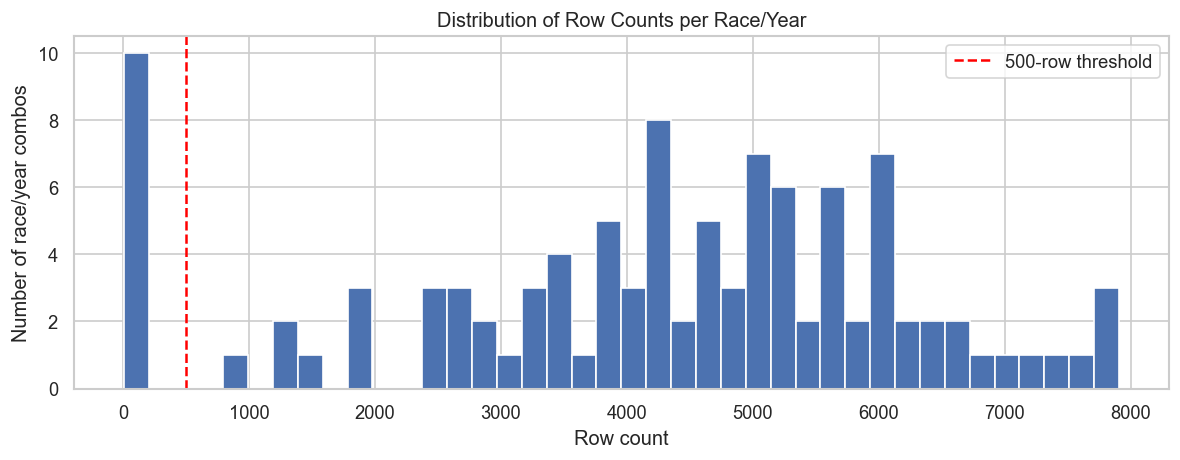


Ghost combos (<500 rows): 10
 Year                      Race  Rows
 2023         French Grand Prix     4
 2022        Chinese Grand Prix     8
 2025         French Grand Prix     8
 2023        Chinese Grand Prix    17
 2023 Emilia Romagna Grand Prix    29
 2024         French Grand Prix    32
 2022      Las Vegas Grand Prix    41
 2022      São Paulo Grand Prix    41
 2022      Abu Dhabi Grand Prix    56
 2022          Qatar Grand Prix    86


In [4]:
# Distribution of row counts — find natural threshold
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(race_row_counts['Rows'], bins=40, color='#4C72B0', edgecolor='white')
ax.axvline(500, color='red', linestyle='--', label='500-row threshold')
ax.set_title('Distribution of Row Counts per Race/Year')
ax.set_xlabel('Row count')
ax.set_ylabel('Number of race/year combos')
ax.legend()
plt.tight_layout()
plt.show()

ghost_combos = race_row_counts[race_row_counts['Rows'] < 500]
print(f'\nGhost combos (<500 rows): {len(ghost_combos)}')
print(ghost_combos.to_string(index=False))

In [5]:
# Check if same ghost combos appear in test — we cannot drop test rows
test_race_counts = test.groupby(['Year', 'Race'])['id'].count().reset_index()
test_race_counts.columns = ['Year', 'Race', 'TestRows']

ghost_in_test = ghost_combos.merge(test_race_counts, on=['Year', 'Race'], how='left')
print('Ghost combos — test row counts:')
print(ghost_in_test[['Year', 'Race', 'Rows', 'TestRows']].to_string(index=False))

Ghost combos — test row counts:
 Year                      Race  Rows  TestRows
 2023         French Grand Prix     4         2
 2022        Chinese Grand Prix     8         3
 2025         French Grand Prix     8         5
 2023        Chinese Grand Prix    17        10
 2023 Emilia Romagna Grand Prix    29        13
 2024         French Grand Prix    32        14
 2022      Las Vegas Grand Prix    41        17
 2022      São Paulo Grand Prix    41        16
 2022      Abu Dhabi Grand Prix    56        28
 2022          Qatar Grand Prix    86        34


In [6]:
# Drop ghost combos from train only
# If a ghost combo exists in test, we must keep it in train for generalisation — flag instead
ghost_keys = set(zip(ghost_combos['Year'], ghost_combos['Race']))

train['is_ghost'] = train.apply(
    lambda r: 1 if (r['Year'], r['Race']) in ghost_keys else 0, axis=1
)

print(f'Ghost rows in train: {train["is_ghost"].sum()}')
print(f'Train rows before drop: {len(train)}')

train = train[train['is_ghost'] == 0].drop(columns='is_ghost').reset_index(drop=True)
print(f'Train rows after drop: {len(train)}')

Ghost rows in train: 322
Train rows before drop: 439140
Train rows after drop: 438818


## 3. Pre-Season Testing — Drop

In [7]:
# Pre-Season Testing is not a race — different strategy logic, no championship points,
# teams run experimental setups. Check if it's in test before dropping.
print('Pre-Season Testing in test?')
print(test[test['Race'] == 'Pre-Season Testing'].shape[0], 'rows')

print(f'\nPre-Season Testing rows in train: {(train["Race"] == "Pre-Season Testing").sum()}')
print(f'Train rows before drop: {len(train)}')

train = train[train['Race'] != 'Pre-Season Testing'].reset_index(drop=True)
print(f'Train rows after drop: {len(train)}')

Pre-Season Testing in test?
9647 rows

Pre-Season Testing rows in train: 22492
Train rows before drop: 438818
Train rows after drop: 416326


## 4. The 2023 Problem

In [8]:
# 2023 pit rate is 0.96% — systematic labelling failure in synthetic generation
# Strategy options:
#   A) Drop 2023 entirely — cleanest signal, lose 25% of data
#   B) Keep 2023 — noisy but model may learn to ignore it with year feature
#   C) Flag with is_2023 feature — let model decide
#
# Decision: Keep 2023 but add is_2023 flag
# Reasoning: 2023 is also in test (58k rows = 31% of test set) — dropping train 2023
# while keeping test 2023 creates a worse distribution mismatch than keeping it

print('Pit rate by year:')
print(train.groupby('Year')['PitNextLap'].agg(['mean', 'count']).assign(
    mean=lambda df: (df['mean'] * 100).round(2)
))

print(f'\n2023 rows in test: {(test["Year"] == 2023).sum()} ({(test["Year"] == 2023).mean():.1%})')

Pit rate by year:
        mean   count
Year                
2022 25.7200   77613
2023  0.9900  128242
2024 30.3200  121804
2025 29.1300   88667

2023 rows in test: 58160 (30.9%)


## 5. Outlier Capping

In [9]:
# LapTime (s): max was 2507s — safety car laps, red flags, formation laps
# A normal F1 lap is 60–180s depending on circuit. Cap at 300s.
# Cumulative_Degradation: max 2412, min -274 — extreme outliers from SC/VSC laps
# Cap at 99th / 1st percentile

for df in [train, test]:
    # LapTime cap
    df['LapTime (s)'] = df['LapTime (s)'].clip(upper=300)
    
    # Cumulative_Degradation — clip to 1st/99th percentile (computed on train)
    cum_deg_lo = train['Cumulative_Degradation'].quantile(0.01)
    cum_deg_hi = train['Cumulative_Degradation'].quantile(0.99)
    df['Cumulative_Degradation'] = df['Cumulative_Degradation'].clip(
        lower=cum_deg_lo, upper=cum_deg_hi
    )

print(f'LapTime (s) after cap: max={train["LapTime (s)"].max():.1f}')
print(f'Cumulative_Degradation after clip: [{train["Cumulative_Degradation"].min():.1f}, {train["Cumulative_Degradation"].max():.1f}]')

LapTime (s) after cap: max=300.0
Cumulative_Degradation after clip: [-206.1, 121.7]


## 6. Feature Engineering

In [10]:
# Compute TotalLaps per race/year for LapsRemaining
race_lengths = train.groupby(['Year', 'Race'])['LapNumber'].max().reset_index()
race_lengths.columns = ['Year', 'Race', 'TotalLaps']

# For test races not in train, fall back to test-derived max
test_lengths = test.groupby(['Year', 'Race'])['LapNumber'].max().reset_index()
test_lengths.columns = ['Year', 'Race', 'TotalLaps']

all_lengths = pd.concat([race_lengths, test_lengths]).groupby(
    ['Year', 'Race'])['TotalLaps'].max().reset_index()

def add_features(df, all_lengths):
    df = df.copy()
    
    # Merge TotalLaps
    df = df.drop(columns=[c for c in ['TotalLaps', 'LapsRemaining'] if c in df.columns])
    df = df.merge(all_lengths, on=['Year', 'Race'], how='left')
    
    # --- Race context ---
    df['LapsRemaining']  = df['TotalLaps'] - df['LapNumber']
    
    # --- Binary flags ---
    df['IsFinalLaps']    = (df['LapsRemaining'] <= 3).astype(int)
    df['IsFirstLap']     = (df['LapNumber'] <= 2).astype(int)
    df['Is2023']         = (df['Year'] == 2023).astype(int)
    
    # --- Stint features ---
    # Stint 2 is the highest-pit-rate stint (39% from EDA)
    df['IsStint2']       = (df['Stint'] == 2).astype(int)
    # Stint number capped at 4 (very few drivers do 5+ stints)
    df['StintCapped']    = df['Stint'].clip(upper=4)
    
    # --- Tyre features ---
    # Median tyre life per compound (from EDA: HARD=17, SOFT=10, INTER=12, MED=11, WET=9)
    compound_median_life = {'HARD': 17, 'MEDIUM': 11, 'SOFT': 10, 
                            'INTERMEDIATE': 12, 'WET': 9}
    df['CompoundMedianLife'] = df['Compound'].map(compound_median_life)
    df['TyreLifeRatio']  = df['TyreLife'] / df['CompoundMedianLife']
    # How many laps past the median life is this tyre?
    df['TyreOverdue']    = (df['TyreLife'] - df['CompoundMedianLife']).clip(lower=0)
    
    # --- Circuit type ---
    # Street circuits have very different pit strategy
    street_circuits = {'Monaco Grand Prix', 'Azerbaijan Grand Prix', 
                       'Singapore Grand Prix', 'Las Vegas Grand Prix',
                       'Saudi Arabian Grand Prix', 'Miami Grand Prix'}
    df['IsStreetCircuit'] = df['Race'].isin(street_circuits).astype(int)
    
    # --- Position_Change: use with caution (inconsistent derivation) ---
    # Clip to realistic range [-10, 10]
    df['Position_Change'] = df['Position_Change'].clip(-10, 10)
    
    return df

train = add_features(train, all_lengths)
test  = add_features(test, all_lengths)

print(f'Train shape after feature engineering: {train.shape}')
print(f'New features: TotalLaps, LapsRemaining, IsFinalLaps, IsFirstLap, Is2023,')
print(f'              IsStint2, StintCapped, CompoundMedianLife, TyreLifeRatio,')
print(f'              TyreOverdue, IsStreetCircuit')

Train shape after feature engineering: (416326, 24)
New features: TotalLaps, LapsRemaining, IsFinalLaps, IsFirstLap, Is2023,
              IsStint2, StintCapped, CompoundMedianLife, TyreLifeRatio,
              TyreOverdue, IsStreetCircuit


In [11]:
# Sanity check new features
print('TyreLifeRatio stats:')
print(train['TyreLifeRatio'].describe().round(3))
print(f'\nPit rate — IsFinalLaps=1: {train[train["IsFinalLaps"]==1]["PitNextLap"].mean():.2%}')
print(f'Pit rate — IsFinalLaps=0: {train[train["IsFinalLaps"]==0]["PitNextLap"].mean():.2%}')
print(f'\nPit rate — IsStint2=1: {train[train["IsStint2"]==1]["PitNextLap"].mean():.2%}')
print(f'Pit rate — IsStint2=0: {train[train["IsStint2"]==0]["PitNextLap"].mean():.2%}')
print(f'\nPit rate — IsStreetCircuit=1: {train[train["IsStreetCircuit"]==1]["PitNextLap"].mean():.2%}')
print(f'Pit rate — IsStreetCircuit=0: {train[train["IsStreetCircuit"]==0]["PitNextLap"].mean():.2%}')

TyreLifeRatio stats:
count   416326.0000
mean         1.0670
std          0.7050
min          0.0590
25%          0.5290
50%          1.0000
75%          1.4710
max          6.9090
Name: TyreLifeRatio, dtype: float64

Pit rate — IsFinalLaps=1: 22.18%
Pit rate — IsFinalLaps=0: 20.17%

Pit rate — IsStint2=1: 39.31%
Pit rate — IsStint2=0: 12.08%

Pit rate — IsStreetCircuit=1: 21.42%
Pit rate — IsStreetCircuit=0: 19.77%


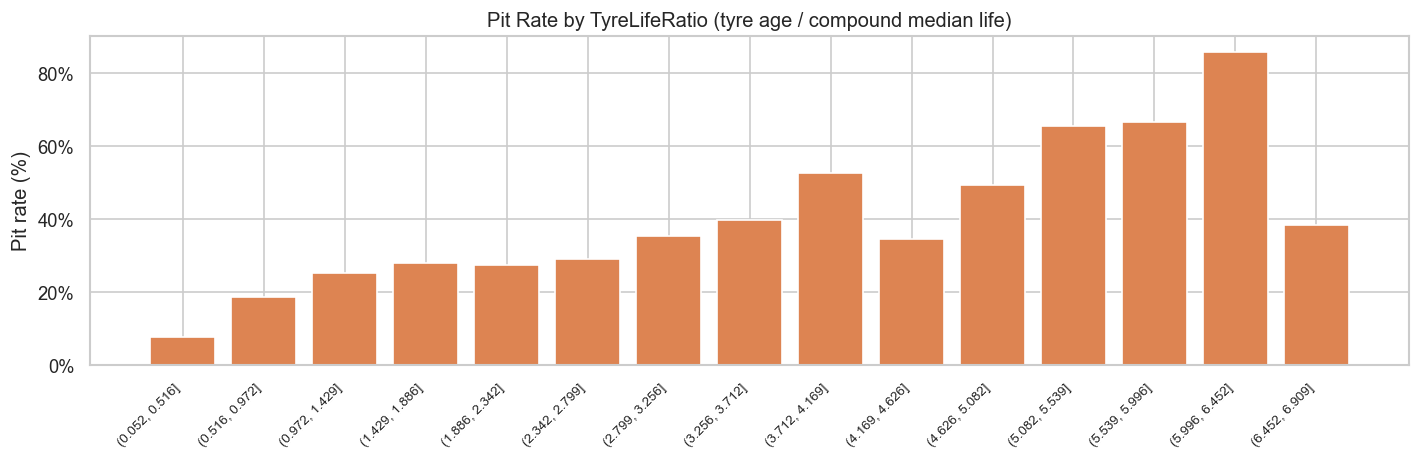

In [12]:
# TyreLifeRatio vs pit rate — confirm signal
train['TLR_bin'] = pd.cut(train['TyreLifeRatio'], bins=15)
tlr_pit = train.groupby('TLR_bin', observed=True)['PitNextLap'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(tlr_pit)), tlr_pit.values * 100, color='#DD8452')
ax.set_xticks(range(len(tlr_pit)))
ax.set_xticklabels([str(b) for b in tlr_pit.index], rotation=45, ha='right', fontsize=8)
ax.set_title('Pit Rate by TyreLifeRatio (tyre age / compound median life)')
ax.set_ylabel('Pit rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()
train.drop(columns='TLR_bin', inplace=True)

## 7. Encoding Categorical Features

In [13]:
# Compound: ordinal encoding — harder compounds last longer
# WET=0, INTERMEDIATE=1, SOFT=2, MEDIUM=3, HARD=4
compound_order = {'WET': 0, 'INTERMEDIATE': 1, 'SOFT': 2, 'MEDIUM': 3, 'HARD': 4}
train['Compound_ord'] = train['Compound'].map(compound_order)
test['Compound_ord']  = test['Compound'].map(compound_order)

print('Compound ordinal encoding:')
print(train.groupby('Compound')['Compound_ord'].first().sort_values())

Compound ordinal encoding:
Compound
WET             0
INTERMEDIATE    1
SOFT            2
MEDIUM          3
HARD            4
Name: Compound_ord, dtype: int64


In [15]:
# Race: target encoding with 5-fold CV to prevent leakage
# We compute target mean per race using out-of-fold estimates on train
# For test, use the global mean per race from full train
from sklearn.model_selection import KFold

def target_encode_race(train, test, col='Race', target='PitNextLap', n_splits=5):
    global_mean = train[target].mean()
    
    # OOF target encoding for train — initialise as float, not string copy
    train_enc = pd.Series(np.nan, index=train.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_idx, val_idx in kf.split(train):
        means = train.iloc[train_idx].groupby(col)[target].mean()
        train_enc.iloc[val_idx] = train.iloc[val_idx][col].map(means).fillna(global_mean)
    
    # Full train mean for test
    race_means = train.groupby(col)[target].mean()
    test_enc = test[col].map(race_means).fillna(global_mean)
    
    return train_enc, test_enc

train['Race_enc'], test['Race_enc'] = target_encode_race(train, test)

print('Race target encoding sample:')
print(train.groupby('Race')[['Race_enc', 'PitNextLap']].first().sort_values(
    'Race_enc', ascending=False).head(10))

Race target encoding sample:
                           Race_enc  PitNextLap
Race                                           
Chinese Grand Prix           0.3918      0.0000
Monaco Grand Prix            0.3594      0.0000
Spanish Grand Prix           0.3185      0.0000
Bahrain Grand Prix           0.2846      1.0000
Belgian Grand Prix           0.2815      0.0000
Emilia Romagna Grand Prix    0.2716      0.0000
São Paulo Grand Prix         0.2560      1.0000
French Grand Prix            0.2548      0.0000
Hungarian Grand Prix         0.2400      0.0000
Saudi Arabian Grand Prix     0.2306      1.0000


## 8. Final Feature Set

In [16]:
FEATURES = [
    # Core tyre
    'TyreLife', 'TyreLifeRatio', 'TyreOverdue', 'CompoundMedianLife', 'Compound_ord',
    # Race context
    'LapNumber', 'RaceProgress', 'LapsRemaining', 'TotalLaps',
    # Stint
    'Stint', 'StintCapped', 'IsStint2',
    # Pre-engineered
    'LapTime (s)', 'Cumulative_Degradation', 'Position_Change',
    # Position
    'Position',
    # Flags
    'IsFinalLaps', 'IsFirstLap', 'Is2023', 'IsStreetCircuit',
    # Encoded categoricals
    'Race_enc', 'Year',
]

TARGET = 'PitNextLap'

# Verify all features exist
missing_features = [f for f in FEATURES if f not in train.columns]
print(f'Missing features: {missing_features}')
print(f'\nFinal feature count: {len(FEATURES)}')
print(f'Train shape: {train[FEATURES].shape}')
print(f'Test shape:  {test[FEATURES].shape}')
print(f'\nAny NaN in train features: {train[FEATURES].isnull().any().any()}')
print(f'Any NaN in test features:  {test[FEATURES].isnull().any().any()}')

Missing features: []

Final feature count: 22
Train shape: (416326, 22)
Test shape:  (188165, 22)

Any NaN in train features: False
Any NaN in test features:  False


In [17]:
# If NaNs exist, check where
nan_cols = train[FEATURES].isnull().sum()
print('NaN counts per feature (train):')
print(nan_cols[nan_cols > 0])

nan_cols_test = test[FEATURES].isnull().sum()
print('\nNaN counts per feature (test):')
print(nan_cols_test[nan_cols_test > 0])

NaN counts per feature (train):
Series([], dtype: int64)

NaN counts per feature (test):
Series([], dtype: int64)


In [18]:
# Final target distribution after cleaning
print('Target distribution after cleaning:')
vc = train[TARGET].value_counts()
print(pd.DataFrame({'count': vc, 'pct': (vc/len(train)*100).round(2)}))
print(f'\nTotal train rows: {len(train)}')
print(f'Rows removed: {439140 - len(train)} ({(439140 - len(train))/439140:.1%})')

Target distribution after cleaning:
             count     pct
PitNextLap                
0.0000      332331 79.8200
1.0000       83995 20.1800

Total train rows: 416326
Rows removed: 22814 (5.2%)


## 9. Save Cleaned Data

In [19]:
# Save full cleaned dataframes (with all columns) for reference
# Save feature-only versions for modelling notebooks

train.to_csv(DATA_DIR / 'train_cleaned.csv', index=False)
test.to_csv(DATA_DIR / 'test_cleaned.csv', index=False)

# Save feature list for downstream notebooks
import json
with open(DATA_DIR / 'feature_list.json', 'w') as f:
    json.dump({'features': FEATURES, 'target': TARGET}, f, indent=2)

print('Saved:')
print(f'  data/train_cleaned.csv  ({len(train)} rows, {train.shape[1]} cols)')
print(f'  data/test_cleaned.csv   ({len(test)} rows, {test.shape[1]} cols)')
print(f'  data/feature_list.json  ({len(FEATURES)} features)')

Saved:
  data/train_cleaned.csv  (416326 rows, 26 cols)
  data/test_cleaned.csv   (188165 rows, 25 cols)
  data/feature_list.json  (22 features)
